In [ ]:
import pandas as pd
import numpy as np

In [ ]:
def generate_bmw_sales_by_date(start_date_str,end_date_str,daily_transactions=3):
  np.random.seed(42)
  start_date=pd.to_datetime(start_date_str)
  end_date=pd.to_datetime(end_date_str)

  total_days=(end_date-start_date).days+1
  n_rows=total_days * daily_transactions

  bmw_cars=['BMW M3 Sedan','BMW X5 SUV','BMW i4 Electric','BMW 7 Series',
          'BMW Z5 Roadstar','BMW iX Electric']
  regions=['Europe','North America','Asia-Pacific','Middle East','Latin America']

  all_dates=pd.date_range(start=start_date,end=end_date)
  random_dates=np.random.choice(all_dates,size=n_rows)

  all_regions=np.random.choice(regions,n_rows)
  indices=np.random.randint(0,len(bmw_cars),n_rows)
  data={
    'OrderID':range(8001,8001+n_rows),
    'Date':sorted(random_dates),
    'Car_Model': [bmw_cars[i] for i in indices],
    'Region':all_regions,
    'Unit_Price':np.round(np.random.uniform(50000,130000,n_rows),2),
    'Units_Sold':np.random.randint(1,4,n_rows)
  }
  df=pd.DataFrame(data)
  df['Total_Revenue']=np.round(df['Unit_Price']*df['Units_Sold'],2)
  return df

In [ ]:
bmw_df=generate_bmw_sales_by_date('2025-04-01','2026-03-31',daily_transactions=2 )

In [ ]:
def query_bmw_sales(region: str = None, car_model: str = None):
    df_data = bmw_df[bmw_df['OrderID'] != 'Total'].copy()

    if region:
        df_data = df_data[df_data['Region'].str.lower() == region.lower()]

    if car_model:
        df_data = df_data[df_data['Car_Model'].str.lower() == car_model.lower()]

    return df_data

In [ ]:
europe_sales = query_bmw_sales(region='Europe')
display(europe_sales)

,OrderID,Date,Car_Model,Region,Unit_Price,Units_Sold,Total_Revenue
1,8002,2025-04-01,BMW Z5 Roadstar,Europe,129022.84,2,258045.68
4,8005,2025-04-02,BMW i4 Electric,Europe,82345.50,1,82345.50
6,8007,2025-04-04,BMW X5 SUV,Europe,107407.82,2,214815.64
8,8009,2025-04-05,BMW M3 Sedan,Europe,129300.48,1,129300.48
10,8011,2025-04-05,BMW i4 Electric,Europe,58328.77,1,58328.77
...,...,...,...,...,...,...,...
717,8718,2026-03-26,BMW Z5 Roadstar,Europe,114206.85,2,228413.70
719,8720,2026-03-26,BMW iX Electric,Europe,91013.42,3,273040.26
720,8721,2026-03-26,BMW Z5 Roadstar,Europe,73479.11,1,73479.11
725,8726,2026-03-30,BMW M3 Sedan,Europe,59107.07,3,177321.21


In [ ]:
!pip install "mcp<2.0.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.6/234.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.5 MB/s eta 0:00:00


In [ ]:
from mcp.server import Server
import mcp.types as types
from mcp.types import TextContent, Tool

In [ ]:
app=Server("BMW Sales Assistant")

In [ ]:
# Define the tools list visible to the LLM
@app.list_tools()
async def list_tools() -> list[types.Tool]:
  return[
      types.Tool(
          name="get_bmw_sales_info",
          description="Filter and return BMW sales data based on region or car model.",
          inputSchema={
              "type": "object",
              "properties":{
                  "region":{
                      "type":"string",
                      "description":"Car model name such as BMW M3 sedan, BMW X5 SUV, etc."
                  }
              }
          }
      )
  ]

In [ ]:
@app.call_tool()
async def call_tool(name: str, arguments: dict) -> list[TextContent]:
  if name == "get_bmw_sales_summary":
    region_arg = arguments.get("region")
    car_model_arg = arguments.get("car_model")
  df_data = bmw_df.copy()
  if region_arg:
    regions =[r.strip()for r in region_arg.split(',')]
    df_data = df_data[df_data['Region'].isin(regions)]
  if car_model_arg:
    models =[m.strip()for m in car_model_arg.split(",")]
    df_data = df_data[df_data['Car_Model'].isin(models)]
  if df_data.empty:
    return[TextContent(type="text", text= "No matching BMW sales records found for the specified criteria")]
  result_str = df_data.to_string(index=False)
  return[TextContent(type="text",text=result_str)]

  raise ValueError(f"Unknown tool: {name}")

In [ ]:
#Test MCP Model
import asyncio

async def run_tests():
  print("--Test 1: Filter by Region(Europe)---")
  # Passing region argument to the tool
  result_europe = await call_tool("get_bmw_sales_summary",{"region":"Europe"})
  print(result_europe[0].text)

  print ("\n--test 2: Filter by Region(North America)---")
  # Passing region argument to the tool
  result_na = await call_tool("get_bmw_sales_summary",{"region":"North America"})
  print(result_na[0].text)

  print ("\n---Test 3: Filter by Region(Asia-Pacific)---" )
  result_asia=await call_tool("get_bmw_sales_summary",{"region":"Asia-Pacific"})
  print(result_asia[0].text)

  print ("\n---Test 4: Filter by Region(Middle East)---")
  result_me=await call_tool("get_bmw_sales_summary",{"region":"Middle East"})
  print(result_me[0].text)

  print('\n---Text 5: Check handling of non-existent data ---')
  # Passing an invaild region to test empty response handing
  result_invalid = await call_tool("get_bmw_sales_summary",{"region":"Mars"})
  print(result_invalid[0].text)

display(bmw_df.head())



,OrderID,Date,Car_Model,Region,Unit_Price,Units_Sold,Total_Revenue
0,8001,2025-04-01,BMW M3 Sedan,North America,89741.35,3,269224.05
1,8002,2025-04-01,BMW Z5 Roadstar,Europe,129022.84,2,258045.68
2,8003,2025-04-01,BMW i4 Electric,Asia-Pacific,60915.18,3,182745.54
3,8004,2025-04-02,BMW X5 SUV,Asia-Pacific,105611.56,3,316834.68
4,8005,2025-04-02,BMW i4 Electric,Europe,82345.50,1,82345.50


In [ ]:
@app.call_tool()
async def call_tool(name: str, arguments: dict) -> list[TextContent]:
    if name == "get_bmw_sales_summary":
      df_data = bmw_df.copy()

      summary =df_data.groupby('Region').agg(
          Total_Cars_Sold=('Units_Sold','sum'),
          Total_Revenue=('Total_Revenue','sum')
         ).reset_index()
      max_sale_region = summary.loc[summary['Total_Cars_Sold'].idxmax()]
      min_sale_region = summary.loc[summary['Total_Cars_Sold'].idxmin()]

      report = (
          f"📊 **BMW Sales Region - Wise Insights:**\n\n"
          f"💫** Top Performing Region:**{max_sale_region['Region']}"
          f"({max_sale_region['Total_Cars_Sold']}cars sold, Revenue: ${max_sale_region['Total_Revenue']:,.2f})\n"
          f"⚠️**Lowest Performing Region:**{min_sale_region['Region']}"
          f"({min_sale_region['Total_Cars_Sold']}cars sold,Revenue: ${min_sale_region['Total_Revenue']:,.2f})\n\n"
          f"📝 **Detailed Breakdown:**\n{summary.to_string(index=False)}"
     )
      return[TextContent(type="text",text=report)]

    raise ValueError(f"Unknown tool: {name}")

In [ ]:
async def test_summary_tool():
  # Call the summary tool we just created
  response = await call_tool("get_bmw_sales_summary",{})

  print(response[0].text)
await test_summary_tool()

styled_df=bmw_df.head(15).style.background_gradient(subset=['Total_Revenue'],cmap='Blues')
display(styled_df)


📊 **BMW Sales Region - Wise Insights:**

💫** Top Performing Region:**Asia-Pacific(311cars sold, Revenue: $27,544,288.63)
⚠️**Lowest Performing Region:**Middle East(236cars sold,Revenue: $20,438,120.94)

📝 **Detailed Breakdown:**
       Region  Total_Cars_Sold  Total_Revenue
 Asia-Pacific              311    27544288.63
       Europe              302    28098430.02
Latin America              293    26449379.54
  Middle East              236    20438120.94
North America              310    27689636.53


,OrderID,Date,Car_Model,Region,Unit_Price,Units_Sold,Total_Revenue
0,8001,2025-04-01 00:00:00,BMW M3 Sedan,North America,89741.350000,3,269224.050000
1,8002,2025-04-01 00:00:00,BMW Z5 Roadstar,Europe,129022.840000,2,258045.680000
2,8003,2025-04-01 00:00:00,BMW i4 Electric,Asia-Pacific,60915.180000,3,182745.540000
3,8004,2025-04-02 00:00:00,BMW X5 SUV,Asia-Pacific,105611.560000,3,316834.680000
4,8005,2025-04-02 00:00:00,BMW i4 Electric,Europe,82345.500000,1,82345.500000
5,8006,2025-04-02 00:00:00,BMW X5 SUV,Latin America,84255.970000,3,252767.910000
6,8007,2025-04-04 00:00:00,BMW X5 SUV,Europe,107407.820000,2,214815.640000
7,8008,2025-04-04 00:00:00,BMW iX Electric,North America,105394.890000,1,105394.890000
8,8009,2025-04-05 00:00:00,BMW M3 Sedan,Europe,129300.480000,1,129300.480000
9,8010,2025-04-05 00:00:00,BMW i4 Electric,Asia-Pacific,60271.540000,3,180814.620000


In [ ]:
import matplotlib.pyplot as plt
import warnings
import seaborn as sns

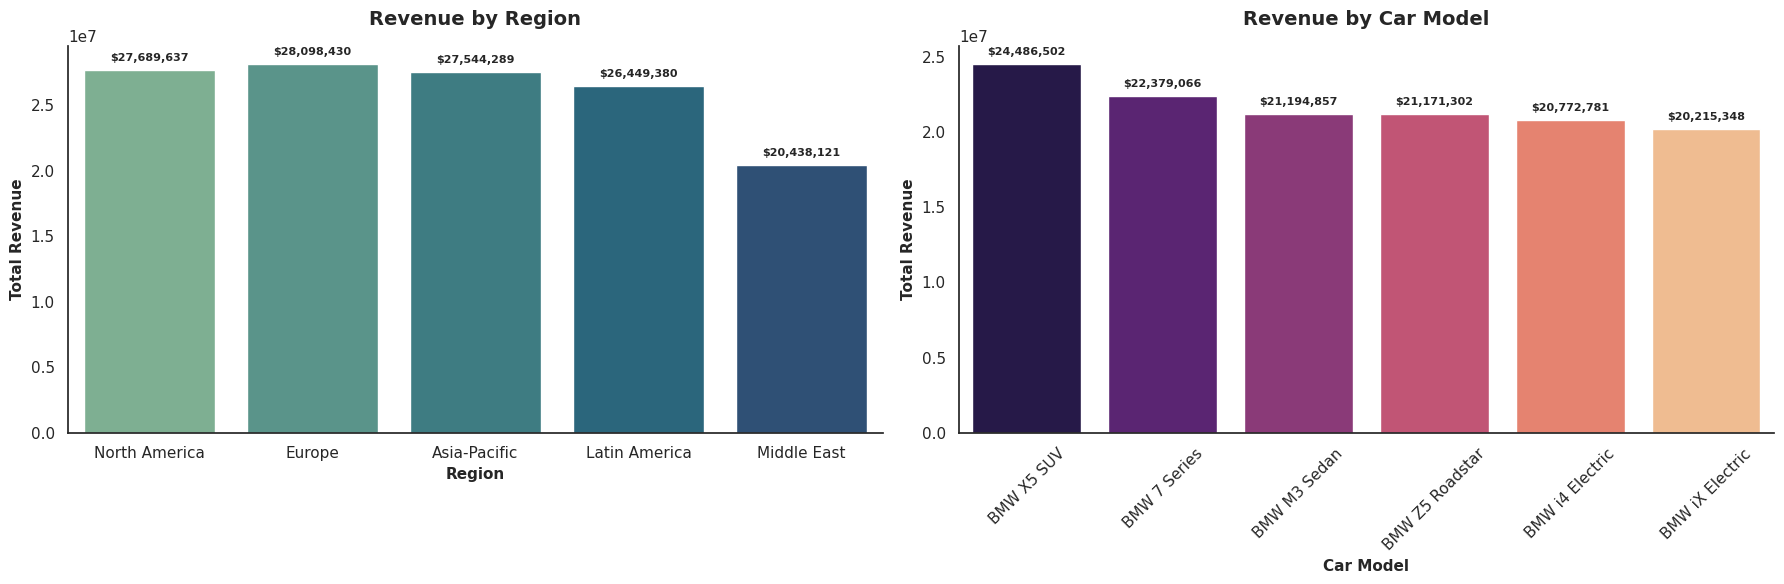

In [ ]:
sns.set_theme(style="white")
warnings.filterwarnings('ignore', category=FutureWarning)

fig, axes = plt.subplots(1, 2, figsize=(18,6))

# Graph 1: Region-wise revenue
ax1 = sns.barplot(
    data=bmw_df,x='Region',y='Total_Revenue',
    estimator=sum, hue='Region',palette='crest',legend=False,errorbar=None,ax=axes[0]
)
axes[0].set_title('Revenue by Region', fontsize=14, fontweight='bold',pad=15)
axes[0].set_xlabel('Region',fontsize=11,fontweight='bold')
axes[0].set_ylabel('Total Revenue',fontsize=11, fontweight='bold')

for p in ax1.patches:
  height = p.get_height()
  if height > 0:
    ax1.annotate(f'${height:,.0f}',(p.get_x()+p.get_width()/2., height),
              xytext=(0,5), textcoords='offset points',ha='center',va='bottom',fontsize=8, weight='bold')

#Graph 2: Car Model-wise Revenue
car_revenue = bmw_df.groupby('Car_Model').agg(Total_Revenue=('Total_Revenue','sum')).reset_index()
car_revenue = car_revenue.sort_values(by='Total_Revenue',ascending=False)

ax2 = sns.barplot(
    data=car_revenue, x='Car_Model',y='Total_Revenue',
    hue='Car_Model', palette='magma',legend=False,errorbar=None,ax=axes[1]
)

axes[1].set_title('Revenue by Car Model',fontsize=14,fontweight='bold',pad=15)
axes[1].set_xlabel('Car Model',fontsize=11,fontweight='bold')
axes[1].set_ylabel('Total Revenue',fontsize=11,fontweight='bold')
axes[1].tick_params(axis='x',rotation=45)

for p in ax2.patches:
  height = p.get_height()
  if height > 0:
    ax2.annotate(f'${height:,.0f}',(p.get_x()+p.get_width()/2., height),
                 xytext=(0,5), textcoords='offset points',ha='center',va='bottom',fontsize=8, weight='bold')
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()